In [ ]:
from datasets import load_dataset
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

dataset = load_dataset("oxai4science/sdoml-lite", streaming=True)

README.md:   0%|          | 0.00/9.78k [00:00<?, ?B/s]

In [ ]:
channels = ['hmi_m', 'aia_0131', 'aia_0171', 'aia_0193', 'aia_0211', 'aia_1600']

def process(data):
    timestamp = data['__key__']
    d = []
    for c in map(lambda x: x+'.npy', channels):
        d.append(np.array(data[c]) if c in data else np.zeros((512, 512)))
    return timestamp, np.stack(d, axis=0)

def plot(timestamp, data):
    import matplotlib.pyplot as plt
    _, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.flatten()
    for i, c in enumerate(channels):
        axs[i].imshow(data[i], cmap='gray')
        axs[i].set_title(c)
        axs[i].axis('off')
    plt.tight_layout()
    plt.suptitle(timestamp)
    plt.subplots_adjust(top=0.94)
    plt.show()

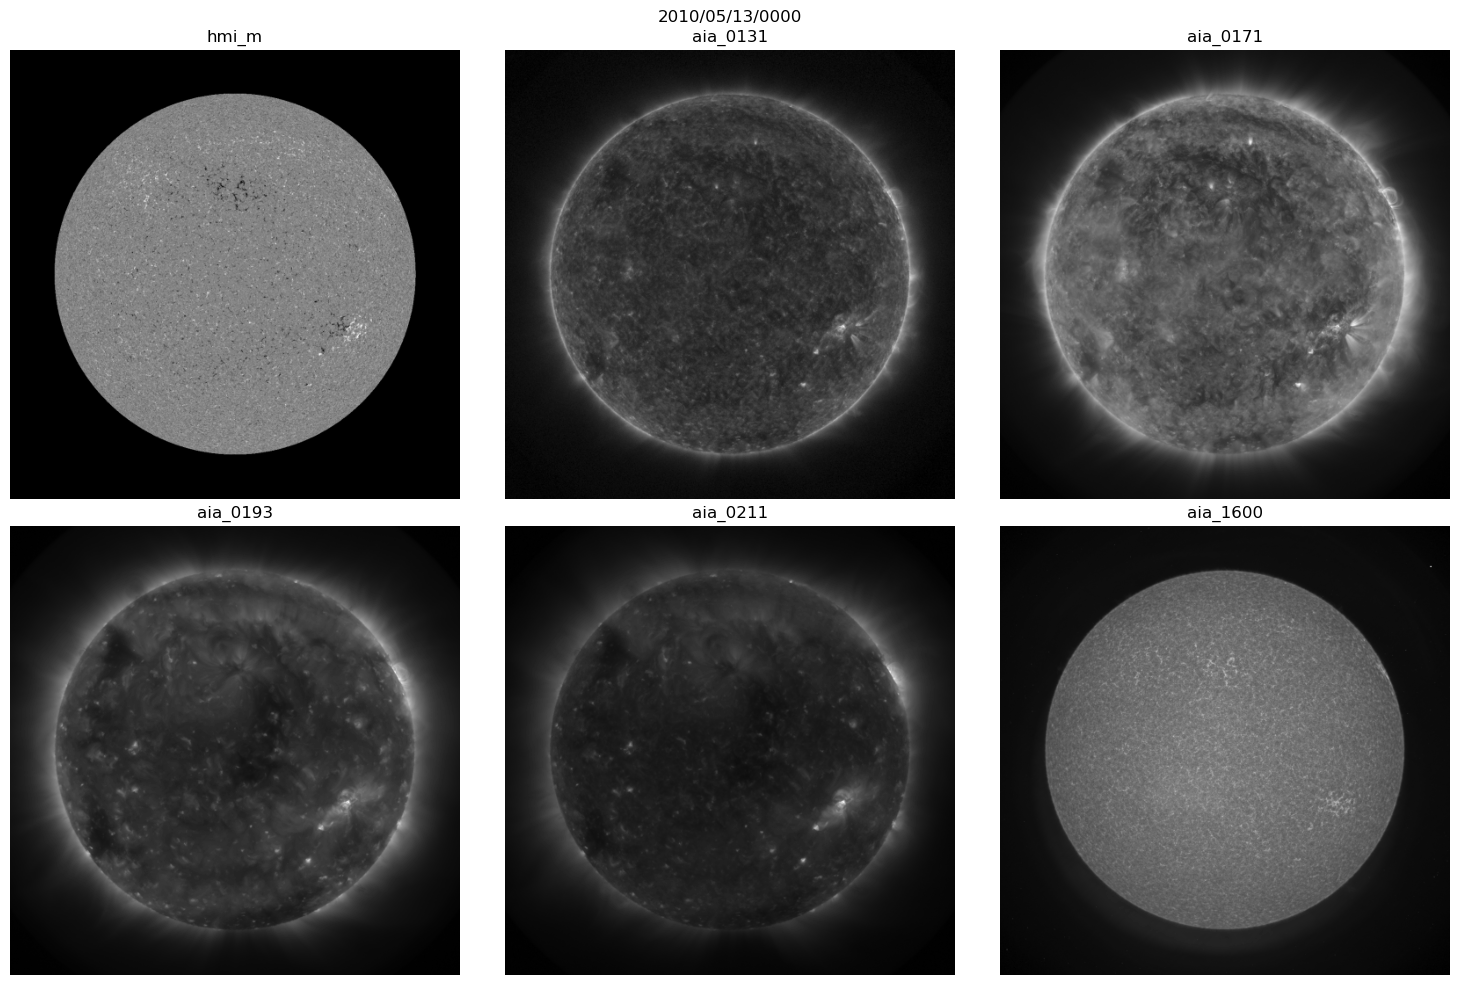

In [ ]:
sample  = next(iter(dataset['train']))
timestamp, data = process(sample)
plot(timestamp, data)

In [ ]:
import torch
from torch.utils.data import IterableDataset, DataLoader

# PyTorch dataset
class SDOMLlite(IterableDataset):
    def __init__(self, dataset_iter):
        self.dataset_iter = dataset_iter

    def __iter__(self):
        for sample in self.dataset_iter:
            t, d = process(sample)
            yield t, torch.tensor(d, dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 8

# Create DataLoader
dataset_iter = iter(dataset['train'])
torch_dataset = SDOMLlite(dataset_iter)
loader = DataLoader(torch_dataset, batch_size=batch_size)

# Training loop
num_epochs = 1
for epoch in range(num_epochs):
    for batch in loader:
        times = batch[0]  # Timestamps
        images = batch[1].to(device) # Images with shape (batch_size, 6, 512, 512)
        print(f"Batch with shape: {images.shape}")
        # ...
        # training code
        # ...
        break
    break

Batch with shape: torch.Size([8, 6, 512, 512])
